In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Sample Dataset
data = {
    'X1': [1,2,3,4,5],
    'X2': [2,3,4,5,6],
    'Y': [10,20,30,40,50]
}
df =pd.DataFrame(data)
print(df)

   X1  X2   Y
0   1   2  10
1   2   3  20
2   3   4  30
3   4   5  40
4   5   6  50


In [3]:
x = df[['X1','X2']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [4]:
#Train the model
model = LinearRegression()
model.fit(X_train,y_train)

#Predict the model
Y_pred = model.predict(X_test)

print('Coefficient: ', model.coef_)
print('Intercept: ', model.intercept_)

Coefficient:  [5. 5.]
Intercept:  -5.0


In [5]:
import numpy as np

# Gradient Descent function
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, c = 0, 0
    n = len(y)

    for _ in range(iterations):
        y_pred = m * X + c

        dm = (-2/n) * np.sum(X * (y - y_pred))
        dc = (-2/n) * np.sum(y - y_pred)

        m -= learning_rate * dm
        c -= learning_rate * dc

    return m, c


X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

m_opt, c_opt = gradient_descent(X, y)

print(f"Optimized values: m = {m_opt}, c = {c_opt}")


Optimized values: m = 1.9951803506719779, c = 0.017400463340610635


In [8]:
#SVM Example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_classes=2, random_state=42, n_informative=2,n_redundant=0, n_repeated=0, n_clusters_per_class=1, class_sep=1.5)

linear_svm  = SVC(kernel='linear')
linear_svm.fit(X,y)

rbf_svm = SVC(kernel='rbf', gamma='scale')
rbf_svm.fit(X,y)

SVC()

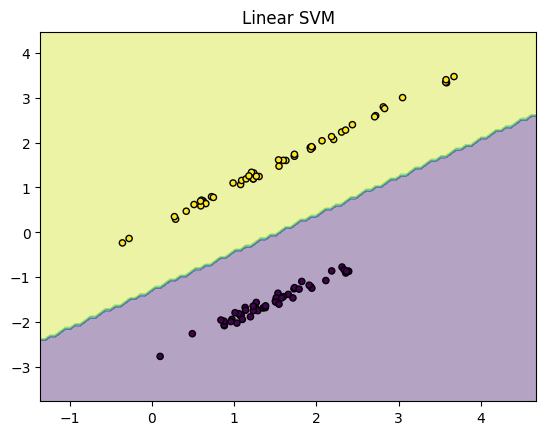

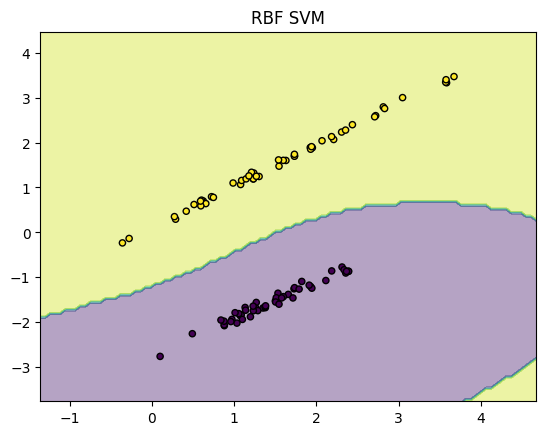

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100,
                                     endpoint=True),
                         np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100,
                                     endpoint=True))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(linear_svm, X, y, 'Linear SVM')
plot_decision_boundary(rbf_svm, X, y, 'RBF SVM')

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

digits = datasets.load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_digits = SVC(kernel='rbf', gamma=0.01, C=10)
svm_digits.fit(X_train, y_train)

y_pred = svm_digits.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

